# 13 — Dissertation Results Figures and Chapter 4 Audit

**Project:** *Deep Learning in Tumor Detection and Mammogram Classification*

This notebook prepares the final Chapter 4 tables and figures from the **saved outputs of the completed experiments**. It does **not train, fine-tune, select, or optimise any model**.

It combines results from:

- V1 ResNet-50 baseline;
- V2 breast-focused ResNet-50;
- ROI-guided ResNet-50;
- ConvNeXt-Tiny backbone replication;
- multimodal image-metadata fusion;
- the predefined ResNet-50 failure-case analysis from Notebook 12.

The notebook also checks the final values against the dissertation numbers agreed from the completed experiment notebooks.

### Scientific rule

The locked test set is used only for final reporting. No model selection or threshold tuning is performed here. The failure cases are reused from Notebook 12, where they were selected algorithmically before visual inspection.

## 1. Mount Google Drive

In [1]:

from pathlib import Path

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    else:
        print("Google Drive is already mounted.")
except ImportError:
    print("Not running in Google Colab. Drive mount skipped.")


Mounted at /content/drive


## 2. Imports, project roots and output folder

In [2]:

import os
import json
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

# The project existed under both names during development.
# This notebook searches both so that old and final saved outputs work.
CANDIDATE_ROOTS = [
    Path("/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification"),
    Path("/content/drive/MyDrive/BreastCancer_dissertation"),
]

ROOTS = [p for p in CANDIDATE_ROOTS if p.exists()]

if ROOTS:
    print("Detected project roots:")
    for p in ROOTS:
        print("  ✓", p)
    PRIMARY_ROOT = ROOTS[0]
else:
    warnings.warn(
        "No expected Google Drive project root was found. "
        "Verified reference values can still be displayed, but saved-output auditing will be limited."
    )
    PRIMARY_ROOT = Path.cwd()

OUTPUT_DIR = PRIMARY_ROOT / "Results" / "13_Dissertation_Figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\nFinal dissertation figures will be saved to:")
print(OUTPUT_DIR)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
})


Detected project roots:
  ✓ /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification
  ✓ /content/drive/MyDrive/BreastCancer_dissertation

Final dissertation figures will be saved to:
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/13_Dissertation_Figures


## 3. Helper functions for saved experiment outputs

In [3]:

def find_result_file(folder_aliases, filename, required=False):
    # Search known project roots for a file inside expected Results subfolders.
    if isinstance(folder_aliases, str):
        folder_aliases = [folder_aliases]

    # Exact expected locations first.
    for root in ROOTS:
        for folder in folder_aliases:
            p = root / "Results" / folder / filename
            if p.exists():
                return p

    # Restricted recursive fallback.
    for root in ROOTS:
        for p in root.rglob(filename):
            parent_text = str(p.parent).lower()
            if any(alias.lower() in parent_text for alias in folder_aliases):
                return p

    if required:
        raise FileNotFoundError(
            f"Could not find {filename} in folders {folder_aliases} under: {ROOTS}"
        )
    return None


def find_root_result_file(filenames, required=False):
    # Find a file saved directly under a project's Results folder.
    if isinstance(filenames, str):
        filenames = [filenames]

    for root in ROOTS:
        for name in filenames:
            p = root / "Results" / name
            if p.exists():
                return p

    for root in ROOTS:
        for name in filenames:
            matches = list(root.rglob(name))
            if matches:
                return matches[0]

    if required:
        raise FileNotFoundError(f"Could not find any of {filenames}")
    return None


def report_file(label, path):
    print(f"{label:34s}: {path if path is not None else 'NOT FOUND'}")


def assert_close(label, observed, expected, tol=5e-4):
    if observed is None or not np.isfinite(observed):
        print(f"⚠ {label}: saved value unavailable; verified reference = {expected:.4f}")
        return expected

    if not np.isclose(float(observed), float(expected), atol=tol):
        raise AssertionError(
            f"{label}: observed {observed:.6f}, expected {expected:.4f}. "
            "Stop and check which saved experiment output was loaded."
        )

    print(f"✓ {label}: {float(observed):.4f}")
    return float(observed)


## 4. Verified final values

These are the final values already checked against the completed experiment notebooks. They are retained here as an audit reference and as a fallback if an older saved-output folder is temporarily unavailable.


In [4]:

VERIFIED_AUC = {
    "V1 baseline": 0.7965,
    "V2 baseline": 0.7795,
    "ResNet control": 0.7771,
    "ResNet ROI": 0.7808,
    "ConvNeXt control": 0.7656,
    "ConvNeXt ROI": 0.7617,
    "M1 image only": 0.7873,
    "M2 metadata only": 0.8154,
    "M3 image + metadata": 0.8598,
    "M4 ROI init + metadata": 0.8644,
}

display(pd.DataFrame(
    [{"Configuration": k, "Verified locked-test ROC-AUC": v}
     for k, v in VERIFIED_AUC.items()]
))


,Configuration,Verified locked-test ROC-AUC
0,V1 baseline,0.7965
1,V2 baseline,0.7795
2,ResNet control,0.7771
3,ResNet ROI,0.7808
4,ConvNeXt control,0.7656
5,ConvNeXt ROI,0.7617
6,M1 image only,0.7873
7,M2 metadata only,0.8154
8,M3 image + metadata,0.8598
9,M4 ROI init + metadata,0.8644


## 5. Locate the completed experiment outputs

In [5]:

# V1 and V2
v1_metrics_path = find_root_result_file([
    "resnet50_mass_baseline_metrics.csv",
    "resnet50_v1_metrics.csv",
])

v2_metrics_path = find_result_file(
    ["resnet50_v2_breastcrop_512"],
    "test_metrics.json"
)

# ROI-guided ResNet-50
resnet_val_path = find_result_file(
    ["06_ROI_Attention", "roi_attention_2class"],
    "validation_by_lambda.csv"
)
resnet_cls_path = find_result_file(
    ["06_ROI_Attention", "roi_attention_2class"],
    "classification_test.csv"
)
resnet_loc_path = find_result_file(
    ["06_ROI_Attention", "roi_attention_2class"],
    "localisation_test.csv"
)
resnet_loc_boot_path = find_result_file(
    ["06_ROI_Attention", "roi_attention_2class"],
    "paired_localisation_bootstrap.csv"
)
resnet_pred_control_path = find_result_file(
    ["06_ROI_Attention", "roi_attention_2class"],
    "test_pred_control_lambda0.csv"
)
resnet_pred_selected_path = find_result_file(
    ["06_ROI_Attention", "roi_attention_2class"],
    "test_pred_selected.csv"
)

# ConvNeXt-Tiny
conv_cls_path = find_result_file(
    ["08_ConvNeXt_ROI", "convnext_roi_attention_2class"],
    "classification_test.csv"
)
conv_loc_path = find_result_file(
    ["08_ConvNeXt_ROI", "convnext_roi_attention_2class"],
    "localisation_test.csv"
)
conv_loc_boot_path = find_result_file(
    ["08_ConvNeXt_ROI", "convnext_roi_attention_2class"],
    "paired_localisation_bootstrap.csv"
)
conv_pred_control_path = find_result_file(
    ["08_ConvNeXt_ROI", "convnext_roi_attention_2class"],
    "test_pred_control_lambda0.csv"
)
conv_pred_selected_path = find_result_file(
    ["08_ConvNeXt_ROI", "convnext_roi_attention_2class"],
    "test_pred_selected.csv"
)

# Multimodal
multimodal_path = find_result_file(
    ["07_Multimodal_Fusion", "multimodal_fusion"],
    "ablation_table.csv"
)

# Notebook 12 failure analysis
failure_summary_path = find_result_file(
    ["12_Failure_Case_Analysis", "failure_case_analysis"],
    "failure_case_summary.csv"
)
failure_metrics_path = find_result_file(
    ["12_Failure_Case_Analysis", "failure_case_analysis"],
    "failure_case_localisation_metrics.csv"
)
failure_panel_path = find_result_file(
    ["12_Failure_Case_Analysis", "failure_case_analysis"],
    "failure_case_panel.png"
)

report_file("V1 metrics", v1_metrics_path)
report_file("V2 metrics", v2_metrics_path)
report_file("ResNet validation ablation", resnet_val_path)
report_file("ResNet locked-test classification", resnet_cls_path)
report_file("ResNet locked-test localisation", resnet_loc_path)
report_file("ConvNeXt locked-test classification", conv_cls_path)
report_file("ConvNeXt locked-test localisation", conv_loc_path)
report_file("Multimodal ablation", multimodal_path)
report_file("Failure-case summary", failure_summary_path)
report_file("Failure-case figure", failure_panel_path)


V1 metrics                        : /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/02_ResNet_V1/resnet50_mass_baseline_metrics.csv
V2 metrics                        : NOT FOUND
ResNet validation ablation        : /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/06_ROI_Attention/validation_by_lambda.csv
ResNet locked-test classification : /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/06_ROI_Attention/classification_test.csv
ResNet locked-test localisation   : /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/06_ROI_Attention/localisation_test.csv
ConvNeXt locked-test classification: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/08_ConvNeXt_ROI/classification_test.csv
ConvNeXt locked-test localisation : /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/08_ConvNeXt

## 6. Load and audit the locked-test ROC-AUC values

In [6]:

# V1
v1_auc = None
if v1_metrics_path is not None:
    v1_df = pd.read_csv(v1_metrics_path)
    if "auc" in v1_df.columns:
        v1_auc = float(v1_df.iloc[0]["auc"])
    elif "roc_auc" in v1_df.columns:
        v1_auc = float(v1_df.iloc[0]["roc_auc"])

# V2
v2_auc = None
if v2_metrics_path is not None:
    with open(v2_metrics_path, "r") as f:
        v2_json = json.load(f)

    if "validation_selected" in v2_json:
        v2_auc = float(v2_json["validation_selected"]["roc_auc"])
    elif "threshold_0_5" in v2_json:
        v2_auc = float(v2_json["threshold_0_5"]["roc_auc"])

# ROI-guided ResNet
resnet_cls = None
if resnet_cls_path is not None:
    resnet_cls = pd.read_csv(resnet_cls_path)

def cls_auc(df, model_name):
    if df is None:
        return None
    row = df[df["model"].astype(str) == model_name]
    return None if row.empty else float(row.iloc[0]["roc_auc"])

resnet_control_auc = cls_auc(resnet_cls, "control_lambda0")
resnet_selected_auc = cls_auc(resnet_cls, "selected")

# ConvNeXt-Tiny
conv_cls = None
if conv_cls_path is not None:
    conv_cls = pd.read_csv(conv_cls_path)

conv_control_auc = cls_auc(conv_cls, "control_lambda0")
conv_selected_auc = cls_auc(conv_cls, "selected")

# Multimodal
mm = None
if multimodal_path is not None:
    mm = pd.read_csv(multimodal_path)

def mm_auc(model_name):
    if mm is None:
        return None
    row = mm[mm["model"].astype(str) == model_name]
    return None if row.empty else float(row.iloc[0]["roc_auc"])

m1_auc = mm_auc("M1_image_only")
m2_auc = mm_auc("M2_metadata_only")
m3_auc = mm_auc("M3_image_meta")
m4_auc = mm_auc("M4_roi_meta")

# Audit against checked final values
audited = {
    "V1 baseline": assert_close("V1 baseline", v1_auc, VERIFIED_AUC["V1 baseline"]),
    "V2 baseline": assert_close("V2 baseline", v2_auc, VERIFIED_AUC["V2 baseline"]),
    "ResNet control": assert_close("ResNet control", resnet_control_auc, VERIFIED_AUC["ResNet control"]),
    "ResNet ROI": assert_close("ResNet ROI", resnet_selected_auc, VERIFIED_AUC["ResNet ROI"]),
    "ConvNeXt control": assert_close("ConvNeXt control", conv_control_auc, VERIFIED_AUC["ConvNeXt control"]),
    "ConvNeXt ROI": assert_close("ConvNeXt ROI", conv_selected_auc, VERIFIED_AUC["ConvNeXt ROI"]),
    "M1 image only": assert_close("M1 image only", m1_auc, VERIFIED_AUC["M1 image only"]),
    "M2 metadata only": assert_close("M2 metadata only", m2_auc, VERIFIED_AUC["M2 metadata only"]),
    "M3 image + metadata": assert_close("M3 image + metadata", m3_auc, VERIFIED_AUC["M3 image + metadata"]),
    "M4 ROI init + metadata": assert_close("M4 ROI init + metadata", m4_auc, VERIFIED_AUC["M4 ROI init + metadata"]),
}


✓ V1 baseline: 0.7965
⚠ V2 baseline: saved value unavailable; verified reference = 0.7795
✓ ResNet control: 0.7771
✓ ResNet ROI: 0.7808
✓ ConvNeXt control: 0.7656
✓ ConvNeXt ROI: 0.7617
⚠ M1 image only: saved value unavailable; verified reference = 0.7873
⚠ M2 metadata only: saved value unavailable; verified reference = 0.8154
⚠ M3 image + metadata: saved value unavailable; verified reference = 0.8598
⚠ M4 ROI init + metadata: saved value unavailable; verified reference = 0.8644


# Chapter 4 tables

The following cells reproduce the main tables discussed for Chapter 4. Where a saved CSV is found, the table is built from that file. Otherwise the already verified final values are used.


## 7. Table 4.1 — Validation ablation for ResNet-50 ROI supervision

In [7]:

if resnet_val_path is not None:
    table_4_1 = pd.read_csv(resnet_val_path)[
        ["lambda", "val_auc", "val_pointing_game", "val_pixel_ap"]
    ].copy()
    table_4_1.columns = ["lambda", "Validation AUC", "Pointing Game", "Pixel-AP"]
else:
    table_4_1 = pd.DataFrame({
        "lambda": [0.0, 0.1, 0.5, 1.0],
        "Validation AUC": [0.6723, 0.6704, 0.6649, 0.6547],
        "Pointing Game": [0.0745, 0.0426, 0.1596, 0.2872],
        "Pixel-AP": [0.1166, 0.0638, 0.1952, 0.3115],
    })

display(table_4_1.round(4))
table_4_1.to_csv(OUTPUT_DIR / "Table_4_1_resnet_validation_lambda_ablation.csv", index=False)


,lambda,Validation AUC,Pointing Game,Pixel-AP
0,0.0,0.6723,0.0745,0.1166
1,0.1,0.6704,0.0426,0.0638
2,0.5,0.6649,0.1596,0.1952
3,1.0,0.6547,0.2872,0.3115


**Table 4.1 caption**

*Validation ablation for ROI-supervision strength. $\lambda=0$ is the identical-architecture control; $\lambda=0.5$ was selected by the predefined validation rule.*


## 8. Table 4.2 — Locked-test ResNet-50 classification

In [8]:

if resnet_cls is not None:
    table_4_2 = resnet_cls[
        ["model", "roc_auc", "pr_auc", "sensitivity", "specificity", "balanced_acc", "f1"]
    ].copy()

    table_4_2["model"] = table_4_2["model"].replace({
        "control_lambda0": "ResNet control, lambda=0",
        "selected": "ResNet ROI, lambda=0.5",
    })
    table_4_2.columns = [
        "Model", "ROC-AUC", "PR-AUC", "Sensitivity",
        "Specificity", "Balanced Acc.", "F1"
    ]
else:
    table_4_2 = pd.DataFrame({
        "Model": ["ResNet control, lambda=0", "ResNet ROI, lambda=0.5"],
        "ROC-AUC": [0.7771, 0.7808],
        "PR-AUC": [0.7297, 0.7271],
        "Sensitivity": [0.8000, 0.8414],
        "Specificity": [0.6111, 0.5000],
        "Balanced Acc.": [0.7056, 0.6707],
        "F1": [0.6725, 0.6507],
    })

display(table_4_2.round(4))
table_4_2.to_csv(OUTPUT_DIR / "Table_4_2_resnet_locked_test_classification.csv", index=False)


,Model,ROC-AUC,PR-AUC,Sensitivity,Specificity,Balanced Acc.,F1
0,"ResNet control, lambda=0",0.7771,0.7297,0.8000,0.6111,0.7056,0.6725
1,"ResNet ROI, lambda=0.5",0.7808,0.7271,0.8414,0.5000,0.6707,0.6507


**Table 4.2 caption**

*Locked-test classification performance for the matched ResNet-50 control and selected ROI-supervised model.*


## 9. Table 4.3 — Locked-test ResNet-50 localisation

In [9]:

resnet_loc = None
if resnet_loc_path is not None:
    resnet_loc = pd.read_csv(resnet_loc_path)

if resnet_loc is not None:
    t = resnet_loc[resnet_loc["subset"].astype(str) == "all"].copy()
    table_4_3 = t[
        ["model", "pointing_game", "pixel_auc", "pixel_ap", "dice@0.5"]
    ].copy()

    table_4_3["model"] = table_4_3["model"].replace({
        "control_lambda0": "lambda=0 control",
        "selected": "lambda=0.5 ROI",
    })
    table_4_3.columns = [
        "Condition", "Pointing Game", "Pixel AUC", "Pixel-AP", "Dice@0.5"
    ]
else:
    table_4_3 = pd.DataFrame({
        "Condition": ["lambda=0 control", "lambda=0.5 ROI"],
        "Pointing Game": [0.0661, 0.1063],
        "Pixel AUC": [0.5787, 0.9053],
        "Pixel-AP": [0.0647, 0.1217],
        "Dice@0.5": [0.0528, 0.0094],
    })

display(table_4_3.round(4))
table_4_3.to_csv(OUTPUT_DIR / "Table_4_3_resnet_locked_test_localisation.csv", index=False)


,Condition,Pointing Game,Pixel AUC,Pixel-AP,Dice@0.5
0,lambda=0 control,0.0661,0.5787,0.0647,0.0528
3,lambda=0.5 ROI,0.1063,0.9053,0.1217,0.0094


**Table 4.3 caption**

*Locked-test localisation for ResNet-50 on all test cases with valid masks.*


## 10. Table 4.4 — ROI-attention effect across ResNet-50 and ConvNeXt-Tiny

In [10]:

# Final paired patient-level bootstrap results from the completed notebooks.
table_4_4 = pd.DataFrame({
    "Backbone": ["ResNet-50", "ConvNeXt-Tiny"],
    "Selected lambda": [0.5, 0.1],
    "Delta Pointing Game [95% CI]": [
        "+0.040 [+0.006, +0.076]",
        "+0.058 [+0.034, +0.084]",
    ],
    "Delta Pixel-AP [95% CI]": [
        "+0.057 [+0.040, +0.075]",
        "+0.077 [+0.062, +0.094]",
    ],
    "Delta AUC [95% CI]": [
        "+0.004 [-0.022, +0.030]",
        "-0.004 [-0.009, +0.001]",
    ],
})

display(table_4_4)
table_4_4.to_csv(OUTPUT_DIR / "Table_4_4_backbone_roi_attention_effect.csv", index=False)


,Backbone,Selected lambda,Delta Pointing Game [95% CI],Delta Pixel-AP [95% CI],Delta AUC [95% CI]
0,ResNet-50,0.5,"+0.040 [+0.006, +0.076]","+0.057 [+0.040, +0.075]","+0.004 [-0.022, +0.030]"
1,ConvNeXt-Tiny,0.1,"+0.058 [+0.034, +0.084]","+0.077 [+0.062, +0.094]","-0.004 [-0.009, +0.001]"


**Table 4.4 caption**

*ROI-attention effect across two convolutional backbones. Localisation differences are supervised minus matched control.*

## 11. Table 4.5 — Multimodal ablation

In [11]:

if mm is not None:
    table_4_5 = mm[
        ["model", "roc_auc", "sensitivity", "specificity", "balanced_acc", "f1"]
    ].copy()

    table_4_5["model"] = table_4_5["model"].replace({
        "M1_image_only": "M1 image only",
        "M2_metadata_only": "M2 metadata only",
        "M3_image_meta": "M3 image + metadata",
        "M4_roi_meta": "M4 ROI init + metadata",
    })

    table_4_5.columns = [
        "Model", "ROC-AUC", "Sensitivity", "Specificity", "Balanced Acc.", "F1"
    ]
else:
    table_4_5 = pd.DataFrame({
        "Model": [
            "M1 image only",
            "M2 metadata only",
            "M3 image + metadata",
            "M4 ROI init + metadata",
        ],
        "ROC-AUC": [0.7873, 0.8154, 0.8598, 0.8644],
        "Sensitivity": [0.8069, 0.7931, 0.8483, 0.8621],
        "Specificity": [0.5509, 0.7037, 0.7917, 0.6806],
        "Balanced Acc.": [0.6789, 0.7484, 0.8200, 0.7713],
        "F1": [0.6518, 0.7099, 0.7859, 0.7375],
    })

display(table_4_5.round(4))
table_4_5.to_csv(OUTPUT_DIR / "Table_4_5_multimodal_ablation.csv", index=False)


,Model,ROC-AUC,Sensitivity,Specificity,Balanced Acc.,F1
0,M1 image only,0.7873,0.8069,0.5509,0.6789,0.6518
1,M2 metadata only,0.8154,0.7931,0.7037,0.7484,0.7099
2,M3 image + metadata,0.8598,0.8483,0.7917,0.8200,0.7859
3,M4 ROI init + metadata,0.8644,0.8621,0.6806,0.7713,0.7375


**Table 4.5 caption**

*Locked-test performance of the multimodal ablation. M3 is the strongest clean multimodal configuration; M4 has the highest raw AUC but no supported AUC gain over M3.*

# Figure 4.1 — Locked-test ROC-AUC across principal CBIS-DDSM configurations

In [12]:

figure_4_1_data = pd.DataFrame({
    "Model": [
        "V1 baseline",
        "V2 baseline",
        "ResNet control\n($\\lambda=0$)",
        "ResNet ROI\n($\\lambda=0.5$)",
        "ConvNeXt control\n($\\lambda=0$)",
        "ConvNeXt ROI\n($\\lambda=0.1$)",
        "M1 image only",
        "M2 metadata only",
        "M3 image + metadata",
        "M4 ROI init + metadata",
    ],
    "ROC-AUC": [
        audited["V1 baseline"],
        audited["V2 baseline"],
        audited["ResNet control"],
        audited["ResNet ROI"],
        audited["ConvNeXt control"],
        audited["ConvNeXt ROI"],
        audited["M1 image only"],
        audited["M2 metadata only"],
        audited["M3 image + metadata"],
        audited["M4 ROI init + metadata"],
    ],
})

display(figure_4_1_data)


,Model,ROC-AUC
0,V1 baseline,0.796520
1,V2 baseline,0.779500
2,ResNet control\n($\lambda=0$),0.777107
3,ResNet ROI\n($\lambda=0.5$),0.780779
4,ConvNeXt control\n($\lambda=0$),0.765581
5,ConvNeXt ROI\n($\lambda=0.1$),0.761750
6,M1 image only,0.787300
7,M2 metadata only,0.815400
8,M3 image + metadata,0.859800
9,M4 ROI init + metadata,0.864400


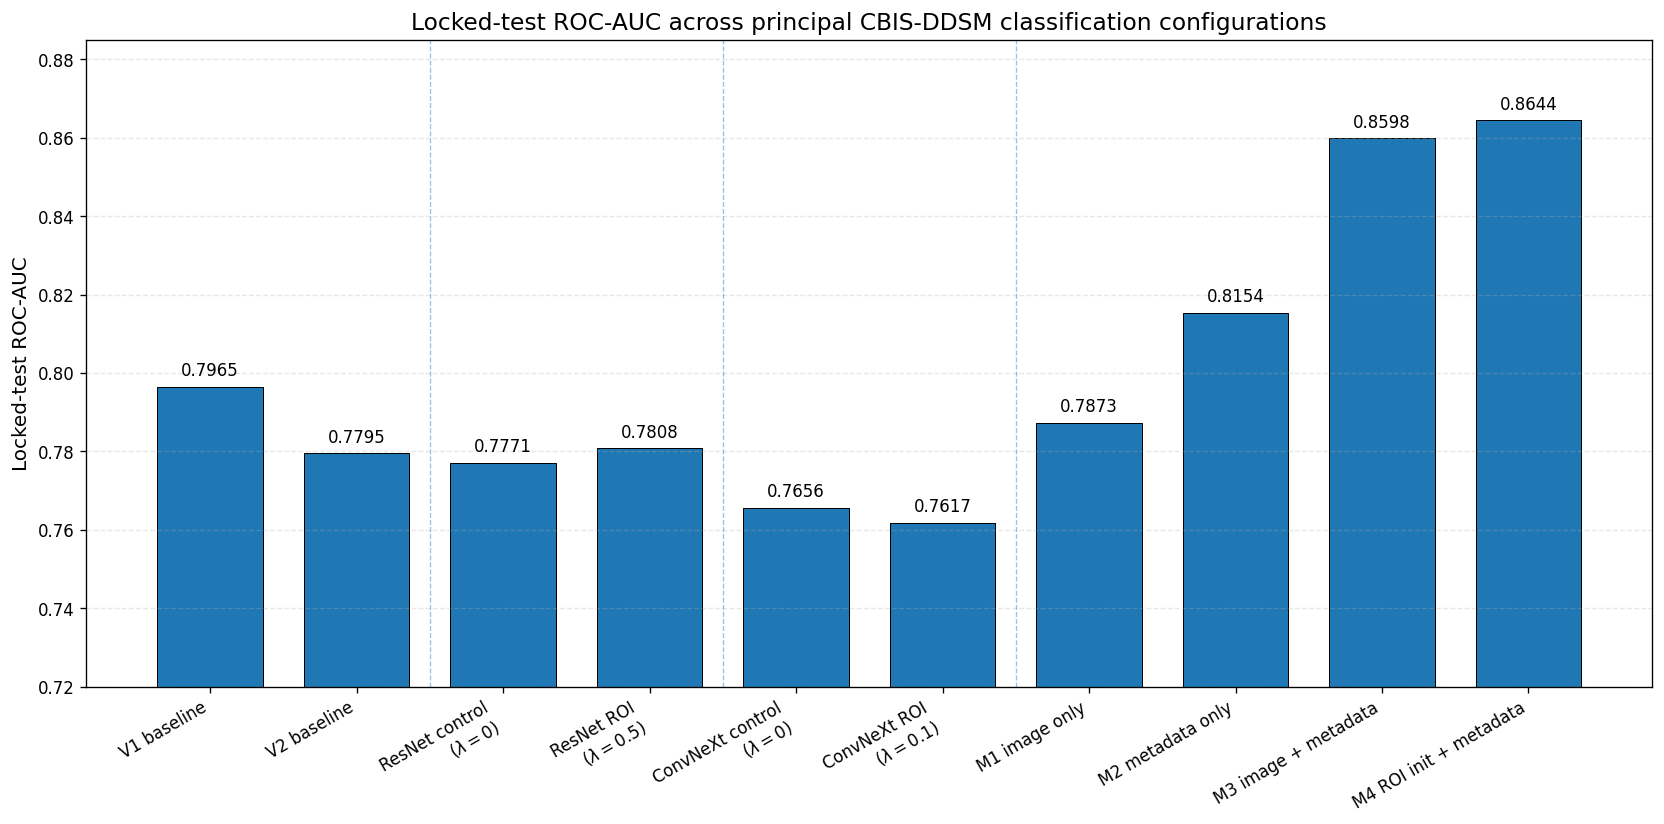

Saved:
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/13_Dissertation_Figures/Figure_4_1_locked_test_roc_auc.png
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/13_Dissertation_Figures/Figure_4_1_locked_test_roc_auc.pdf


In [13]:

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(figure_4_1_data))
values = figure_4_1_data["ROC-AUC"].to_numpy()

bars = ax.bar(
    x,
    values,
    width=0.72,
    edgecolor="black",
    linewidth=0.6,
)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.0018,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    figure_4_1_data["Model"],
    rotation=30,
    ha="right",
)

ax.set_ylabel("Locked-test ROC-AUC")
ax.set_ylim(0.72, 0.885)

ax.set_title(
    "Locked-test ROC-AUC across principal CBIS-DDSM classification configurations"
)

ax.grid(axis="y", linestyle="--", alpha=0.30)

for boundary in [1.5, 3.5, 5.5]:
    ax.axvline(
        boundary,
        linestyle="--",
        linewidth=0.8,
        alpha=0.45,
    )

fig.tight_layout()

fig4_1_png = OUTPUT_DIR / "Figure_4_1_locked_test_roc_auc.png"
fig4_1_pdf = OUTPUT_DIR / "Figure_4_1_locked_test_roc_auc.pdf"

fig.savefig(fig4_1_png, dpi=300, bbox_inches="tight")
fig.savefig(fig4_1_pdf, bbox_inches="tight")

plt.show()

print("Saved:")
print(fig4_1_png)
print(fig4_1_pdf)


### Figure 4.1 caption

*Locked-test ROC-AUC across the principal CBIS-DDSM classification configurations. Values are taken directly from the saved outputs of the baseline, ROI-guided ResNet-50, ConvNeXt-Tiny backbone-replication and multimodal experiments. The models address the same benign-versus-malignant task, although individual training configurations differ.*

# Figure 4.2 — ResNet-50 failure-case analysis

Notebook 12 already performs the correct failure-case procedure:

- no retraining;
- the frozen matched control and selected ROI-supervised ResNet-50 are reused;
- the false negative is selected as the malignant false negative with the **lowest malignant probability**;
- the false positive is selected as the non-malignant false positive with the **highest malignant probability**;
- selection occurs before visual inspection;
- the mammogram, expert ROI, true-class CAMs, decision-class CAMs and case-level localisation metrics are compared.

This notebook therefore **reuses the saved Notebook 12 outputs** rather than selecting new examples.


In [14]:

failure_summary = None
failure_metrics = None

if failure_summary_path is not None:
    failure_summary = pd.read_csv(failure_summary_path)
    print("Failure-case summary:")
    display(failure_summary.T)

    ids = set(failure_summary["patient_id"].astype(str))
    expected_ids = {"P_00932", "P_00490"}

    if expected_ids.issubset(ids):
        print("✓ Predefined failure cases confirmed: P_00932 and P_00490")
    else:
        warnings.warn(
            f"Expected failure patients {expected_ids}, but loaded {ids}. "
            "Check that the final Notebook 12 output was used."
        )
else:
    print("⚠ failure_case_summary.csv not found. Run completed Notebook 12 first.")

if failure_metrics_path is not None:
    failure_metrics = pd.read_csv(failure_metrics_path)
    print("\nCase-level localisation metrics:")
    display(failure_metrics.round(4))
else:
    print("⚠ failure_case_localisation_metrics.csv not found.")


Failure-case summary:


,0,1
case,False negative,False positive
sample_id,P_00932|LEFT|MLO,P_00490|RIGHT|CC
patient_id,P_00932,P_00490
laterality,LEFT,RIGHT
view,MLO,CC
ground_truth,malignant,non-malignant
control_prediction,non-malignant,malignant
control_p_malignant,0.1533,0.963016
control_threshold,0.44,0.44
selected_prediction,non-malignant,malignant


✓ Predefined failure cases confirmed: P_00932 and P_00490

Case-level localisation metrics:


,case,sample_id,model,true_class,pointing_game,pixel_auc,pixel_ap,dice@0.5
0,False negative,P_00932|LEFT|MLO,control_lambda0,1,0,0.9365,0.0106,0.0042
1,False negative,P_00932|LEFT|MLO,roi_supervised,1,0,0.9689,0.0212,0.0029
2,False positive,P_00490|RIGHT|CC,control_lambda0,0,0,0.2201,0.0011,0.0037
3,False positive,P_00490|RIGHT|CC,roi_supervised,0,0,0.9384,0.0127,0.0035


### Expected final cases from Notebook 12

- **False negative:** `P_00932`, left MLO, malignant, selected-model $p(\mathrm{malignant}) \approx 0.073$.
- **False positive:** `P_00490`, right CC, non-malignant, selected-model $p(\mathrm{malignant}) \approx 0.992$.

For both cases, Pointing Game remained 0 for the matched control and ROI-supervised model. The pixel-ranking metrics improved, but the strongest activation still did not move inside the annotated lesion. This should be reported factually in Chapter 4 and interpreted more cautiously in Chapter 5.

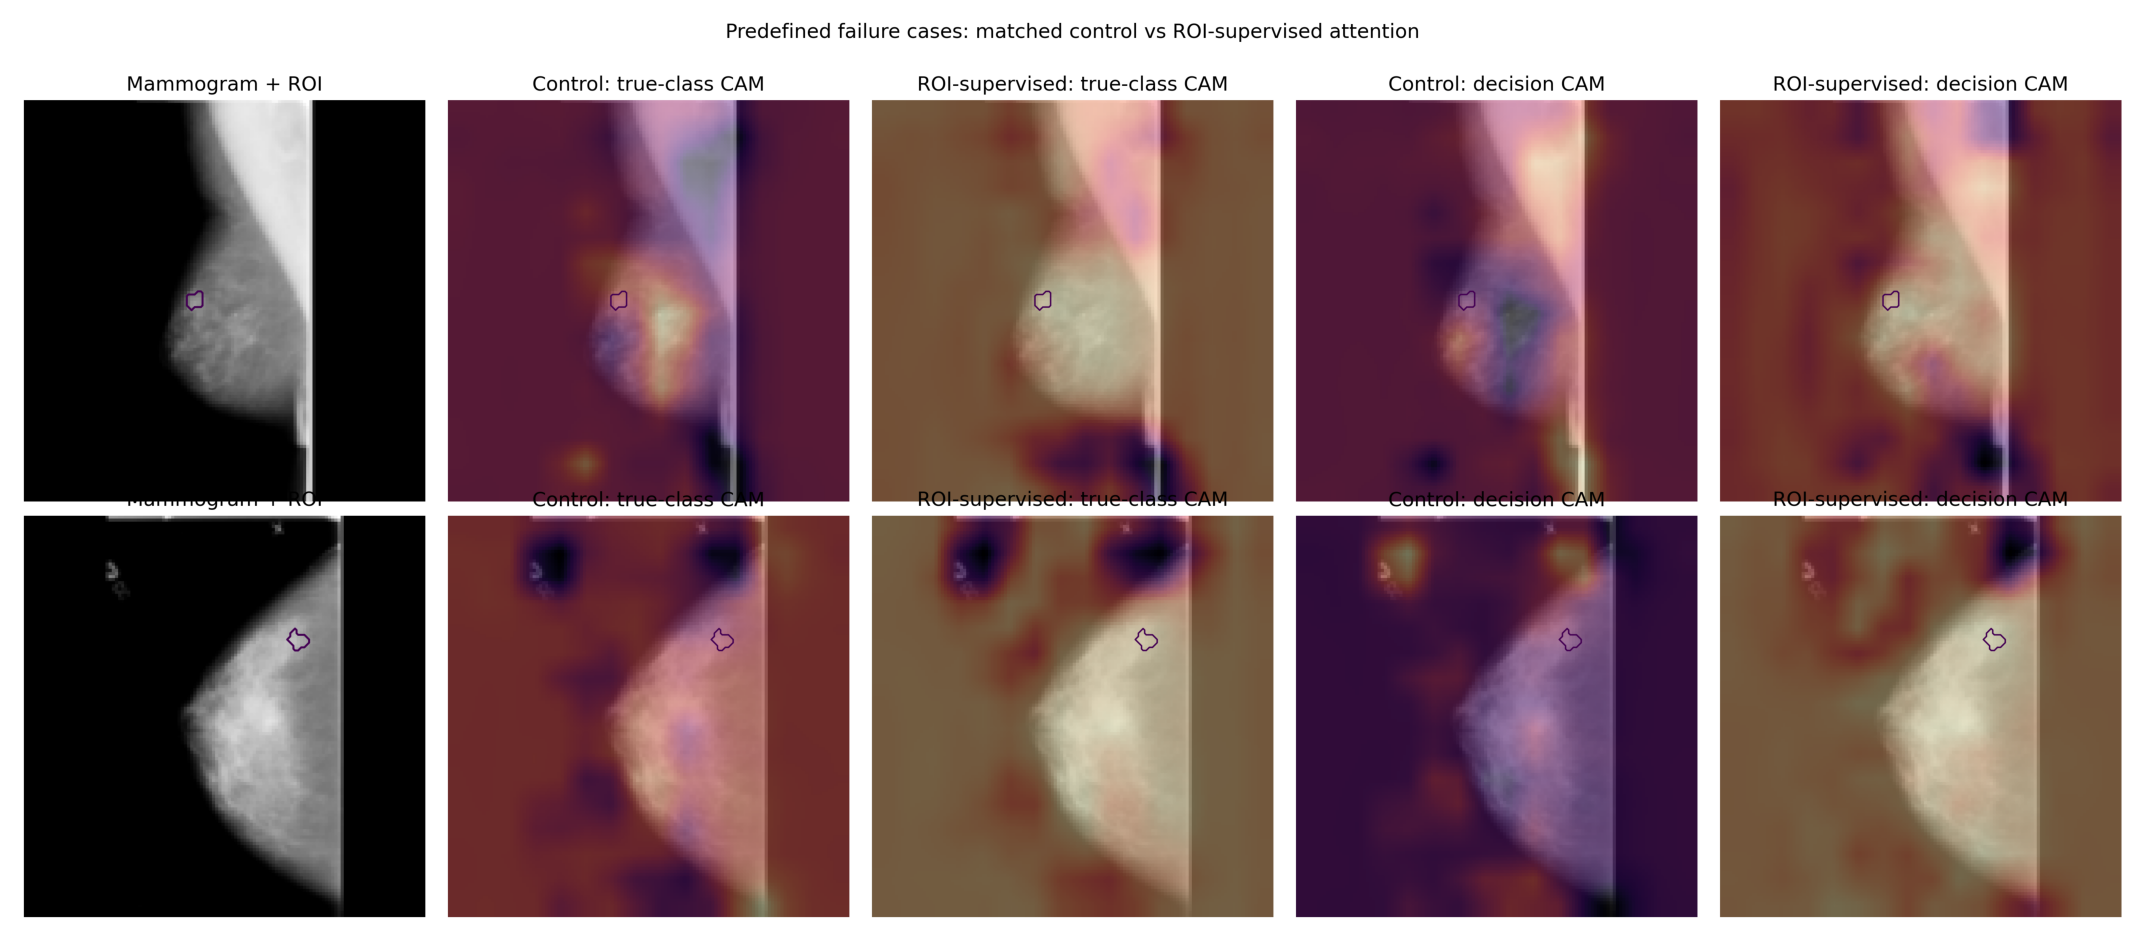

Saved dissertation copy:
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/13_Dissertation_Figures/Figure_4_2_resnet_failure_cases.png


In [15]:

if failure_panel_path is not None:
    fig4_2_png = OUTPUT_DIR / "Figure_4_2_resnet_failure_cases.png"
    shutil.copy2(failure_panel_path, fig4_2_png)

    img = Image.open(fig4_2_png)

    plt.figure(figsize=(18, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("Saved dissertation copy:")
    print(fig4_2_png)
else:
    print(
        "⚠ failure_case_panel.png was not found.\n"
        "Run the completed Notebook 12 once, then rerun this cell.\n"
        "Do not manually choose replacement failure cases."
    )


### Suggested Figure 4.2 caption

*Predefined locked-test failure cases for the selected ROI-supervised ResNet-50 compared with the matched $\lambda=0$ control. The false negative and false positive were selected algorithmically before visual inspection. Each row shows the mammogram with expert ROI, control and ROI-supervised true-class CAMs, and the corresponding decision-class CAMs.*

### How to discuss Figure 4.2

**Chapter 4 — Results:** report only what is directly observed: the ground truth, prediction, malignancy probability, whether the activation peak lies inside the ROI, and the case-level localisation metrics.

**Chapter 5 — Discussion:** possible contributors such as very small lesion area, tissue overlap or ill-defined margins may be discussed only as plausible interpretations, not proven causes.

## 14. Final output audit

In [16]:

print("Files created in:", OUTPUT_DIR)
print("-" * 70)

for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file():
        print(f"{p.name:55s} {p.stat().st_size / 1024:.1f} KB")


Files created in: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/13_Dissertation_Figures
----------------------------------------------------------------------
Figure_4_1_locked_test_roc_auc.pdf                      21.0 KB
Figure_4_1_locked_test_roc_auc.png                      352.3 KB
Figure_4_2_resnet_failure_cases.png                     392.0 KB
Table_4_1_resnet_validation_lambda_ablation.csv         0.3 KB
Table_4_2_resnet_locked_test_classification.csv         0.3 KB
Table_4_3_resnet_locked_test_localisation.csv           0.2 KB
Table_4_4_backbone_roi_attention_effect.csv             0.3 KB
Table_4_5_multimodal_ablation.csv                       0.3 KB


## 15. Optional: download the final figures from Colab

Run this only when you want local copies.